In [1]:
from pyrootmemo import Parameter
from pyrootmemo.materials import MultipleRoots, Soil, Interface
from pyrootmemo.geometry import SoilProfile, FailureSurface
from pyrootmemo.models import Waldron

# Waldron (direct shear)

The `Waldron` model implements the direct-shear displacement driven models by
[Waldron (1977)](https://doi.org/10.2136/sssaj1977.03615995004100050005x), 
[Waldron & Dakessian (1981)](https://doi.org/10.1097/00010694-198112000-00007)

The implementation in pyrootmemo adds some further functionality beyond these 
papers, such as inclusion of slippage, root elasto-plasticity and
three-dimensional initial root orientations, aligned with principles in the 
DRAM model by [Meijer et al. (2022)](https://doi.org/10.1016/j.ecoleng.2022.106621).


## Create model objects

### Roots

Define some roots, using the `MultipleRoots` class. The WWM model requires the 
following root attributes to be defined:

* Root diameter: (`diameter`)
* Root tensile strength (`tensile strength`)
* Root elastic stiffness (`elastic_modulus`)
* Root tensile strenth (`tensile_strength`)

Optionally, initial (three-dimensional) root orientations can be specified. 
These are defined in a *global* coordinate system, where the $z$-axis points 
upwards (so $z$ is analogous with the surface elevation). By default, all roots
are assumed purely vertical, i.e. pointing in the z-direction.

These orientatoins can be altered by using two subsequent rotations

* Azimuth angle: (`azimuth_angle`): rotates the root around the $z$-axis (positive from $x$ to $y$)
* Azimuth angle (`elevation_angle`): rotates the root around the (now rotated) $y$-axis (positive from $z$ to $x$)

The initial root orientation for each root is thus uniquely described by a vector:

$$ \begin{bmatrix} \cos\alpha \sin\beta \\ \sin\alpha \sin\beta \\ \cos\beta \end{bmatrix} $$

where $\alpha$ is the azimuth angle and $\beta$ the elevation angle.

In [2]:
roots = MultipleRoots(
    species = 'test_species',
    diameter = Parameter([1, 2, 3, 4], 'mm'),
    elastic_modulus = Parameter([600, 500, 400, 300], 'MPa'),
    tensile_strength = Parameter([50, 30, 10, 8], 'MPa'),
    azimuth_angle = Parameter([0, 0, 0, 0], 'degrees'),
    elevation_angle = Parameter([0, 10, 20, 30], 'degrees')
    )

In [3]:
import numpy as np
a = roots.diameter
b = roots.tensile_strength
a[np.newaxis, :]*b[:, np.newaxis]

Magnitude,[[ 50 100 150 200] [ 30 60 90 120] [ 10 20 30 40] [ 8 16 24 32]]
Units,megapascal millimeter


In [4]:
a = np.random.rand(4, 5)
b = np.random.rand(5)
print(a + b)

[[1.6319079  0.65955022 1.06808722 0.86485311 1.39001548]
 [1.57048868 0.85435016 1.39159803 0.67773644 1.59255956]
 [1.69455707 0.44318281 0.96585124 1.11303166 1.36443894]
 [0.85407711 0.70679173 0.82604875 1.59623246 1.2228271 ]]


In [5]:
print(np.shape(4))

()


### Soil

Create a soil profile, consisting of one or more soils. For example, at 20 m
thick sand deposit. 

Only the friction angle is required. This is the only soil parameter that the 
Waldron model requires.

In [6]:
sand = Soil(
    'sand',
    friction_angle = Parameter(30, 'degrees')
    )

profile = SoilProfile(
    [sand],
    depth = Parameter([20], 'm'),
    )


### Soil-root interface

The strength of the interface between soil and roots needs to be defined. This 
is done through an `Interface` object:

In [7]:
interface = Interface(
    shear_strength = Parameter(10, 'kPa')
    )

### Failure surface

Finally, define a failure surface, which needs a cross-sectional area,
failure depth, and a shear zone thickness.

By default, the failure surface is assumed to be horizontal (so the global 
$z$-direction is perpendicular to the failure surface) and is assumed to move
in the global $x$-direction. 

These directions and orientations can be changed by using the optional 
`azimuth_angle` and `elevation_angle` arguments. The azimuth rotates the global 
coordinate system around the global $z$-axis (positive from $x$ to $y$). 
The elevation angle subsequent rotates the (now-rotated) coordinate system 
further by rotating around the (now-rotated) $y$-axis (positive from $z$ to
$x$). 

For the geologists among you, `azimuth` is equal to the negative value of the 
strike angle (assuming $x$ points east and $y$ points north), and `elevation` 
is equal to the dip angle. The sliding mass moves in the direction of the 
(largest) dip.

In [8]:
surface = FailureSurface(
    cross_sectional_area = Parameter(1.0, 'm^2'),
    depth = Parameter(5.0, 'm'),
    shear_zone_thickness = Parameter(100, 'mm'),
    azimuth_angle = Parameter(0, 'degrees'),
    elevation_angle = Parameter(20, 'degrees')
    )

### Model

With these root and soil geometry objects created, finally create the 
object describing the model. Waldron and Dakessian's model only accounts for 
elastic, suddenly breaking roots.

In [9]:
waldron = Waldron(roots, interface, profile, surface)

pyrootmemo's implementation expands on this by also allowing slipping and/or
elasto-plastic behaviour (similar to the DRAM model by Meijer et al.) and 
Weibull failure (similar to the RBMw by Schwarz et al.). By default, the most
sophisticated model is selected that can be supported by the user input.

* breakage is included when the `MultipleRoots` object has been assigned a `tensile_strength` attribute.
* slipping is included when the `MultipleRoots` have been assigned a `length` attribute.
* elasto-plasticity is included when the `MultipleRoots` have been assigned both a `plastic_modulus` and `yield_strength` attribute
* weibull failure is included when a Weibull shape parameter is define when creating the Waldron class, using the `weibull_shape' input argument.

You can check what behaviour is allowed by querying the `breakage`, `slippage`
and/or the `elastoplastic` attributes of the model class.

In [10]:
print(waldron.breakage)
print(waldron.slipping)
print(waldron.elastoplastic)

True
False
False


If you want to fix a specific type of behaviour, you can force certain behaviour 
when creating the model. For example, to disable root breakage:


In [11]:
waldron2 = Waldron(roots, interface, profile, surface, breakage = False)

But let's ignore this extra complexity for now.

In [12]:
from pyrootmemo.helpers import outer_ufunc
a = np.array([1])
b = np.array([1, 2, 3])
print(outer_ufunc(a, b))

[[1. 2. 3.]]


## Calculations

Various calculations can be made. The method calculated results are returned
depends on the "results" input argument that can be defined for each calculation
function:

* `results = "attribute"` (default behaviour): calculated model results are 
stored in a dictionary in the `output` attribute of the class.
* `results = "return"`: functions returns a dictionary with results, without 
writing to class' `output` attribute
* `results = "both"`: functions both returns dictionary output *and* writes 
to the `output` attribute.
 
### Reinforcement at specified displacement (`calc_reinforcement()`)

In [ ]:
displacement = Parameter(10.0, 'mm')
waldron.calc_reinforcement(displacement)

print(waldron.output['displacement'])
print(waldron.output['reinforcement'])
print(waldron.output['reinforcement_per_root'])
print(waldron.output['force_per_root'])

[10.0] millimeter
10.0 millimeter
34.364221849951626 newton / meter ** 2
[0.0 0.0 7.770134459877726 26.594087390073902] newton / meter ** 2


The function also returns some information about the type of root behaviour.
The types and the fraction of total root cross-sectional area that behaves 
according to each type can be accessed by:

In [14]:
print(waldron.output['behaviour_types'])
print(waldron.output['behaviour_fraction'])

['Anchored, elastic' 'Anchored, plastic' 'Full pullout, elastic'
 'Full pullout, plastic' 'Not in tension' 'Slipping, elastic'
 'Slipping, plastic']
[0.83333333 0.         0.         0.         0.16666667 0.
 0.        ]


This function is vectorised, so multiple displacement steps can be computed
at ones:

In [15]:
displacement = Parameter([10, 40, 100], 'mm')
waldron.calc_reinforcement_vectorised(displacement)

print(waldron.output['displacement'])
print(waldron.output['reinforcement'])
print(waldron.output['reinforcement_per_root'])

print(waldron.output['behaviour_types'])
print(waldron.output['behaviour_fraction'])

AttributeError: 'Waldron' object has no attribute 'calc_reinforcement_vectorised'

### Peak reinforcement (`calc_peak_reinforcement()`)

To calculat the peak reinforcement, as well as the level of shear displacement 
at which this occurs, first call the `calc_peak_reinforcement()` function and
then request the results from the model's `output` dictionary.

In [ ]:
waldron.calc_peak_reinforcement()

print(waldron.output['peak_displacement'])
print(waldron.output['peak_reinforcement'])

53.74427689044917 millimeter
0.18373169456906807 kilopascal


## Plotting (`plot()`)

The results of the Waldron model can be plotted using the `plot()` method.

To create a basic plot:

<Axes: xlabel='Shear displacement [mm]', ylabel='Reinforcement [kPa]'>

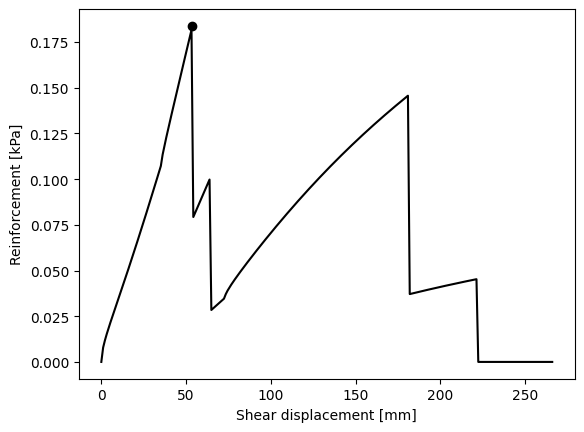

In [ ]:
waldron.plot()

To show the contributions of each individual root:

<Axes: xlabel='Shear displacement [mm]', ylabel='Reinforcement [kPa]'>

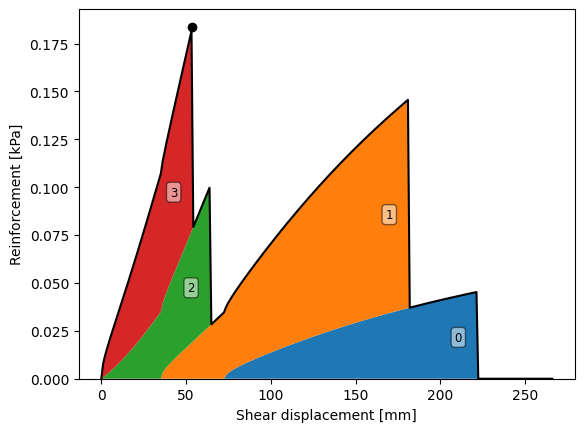

In [ ]:
waldron.plot(stack = True)

You can see that the first two roots do not mobilise any resistance until some
shear displacement has occured. This is because of their initial orientation,
relative to the defined failure surface, is initially unfavourable for
developing tension.